# **Email Spam Classification using Machine Learning**

**Project:** Machine Learning Internship - Month 1  
**Task:** Build a machine learning model to classify messages as **spam** or **ham/not spam**.


## **1. Import Required Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("Successfully import libraries")

Successfully import libraries


## **2. Upload and Load Dataset**



In [5]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Email_dataset.csv", encoding="latin-1")
df.head()

Saving Email_dataset.csv to Email_dataset.csv


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## **3. Understand Dataset Structure**

In [6]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (5572, 5)

Columns:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Missing values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## **4. Clean Dataset**



In [7]:
# Keep only useful columns
df = df[["v1", "v2"]].copy()

# Rename columns for clarity
df.columns = ["label", "message"]

# Basic cleaning
df["label"] = df["label"].astype(str).str.strip().str.lower()
df["message"] = df["message"].astype(str)

# Keep only valid classes
df = df[df["label"].isin(["ham", "spam"])]

# Remove duplicate messages
before = len(df)
df = df.drop_duplicates(subset=["message"]).reset_index(drop=True)
after = len(df)

print(f"Rows before duplicate removal: {before}")
print(f"Rows after duplicate removal: {after}")

# Encode labels: ham=0, spam=1
df["target"] = df["label"].map({"ham": 0, "spam": 1})

display(df.head())

Rows before duplicate removal: 5572
Rows after duplicate removal: 5169


,label,message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## **5. Exploratory Data Analysis**

label
ham     4516
spam     653
Name: count, dtype: int64


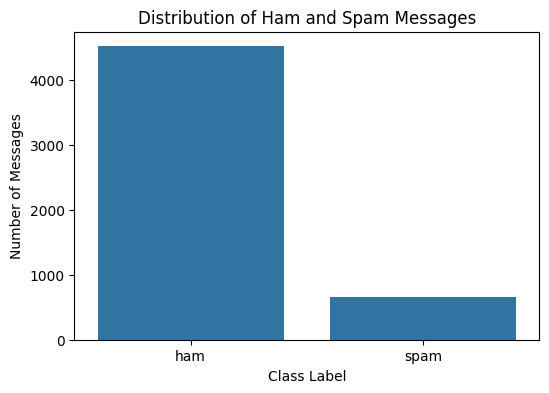

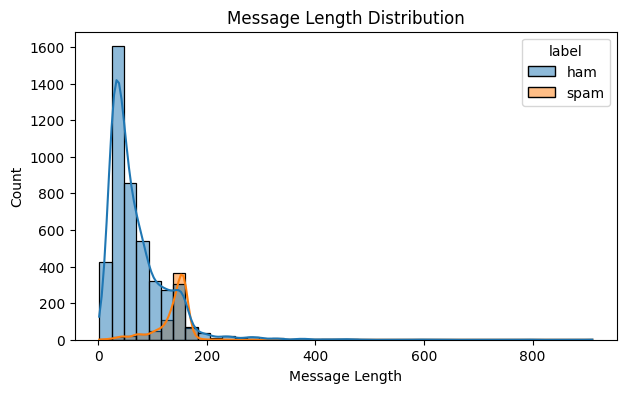

In [8]:
print(df["label"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Class Label")
plt.ylabel("Number of Messages")
plt.show()

df["message_length"] = df["message"].apply(len)

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="message_length", hue="label", bins=40, kde=True)
plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.show()

## **6. Text Preprocessing Function**

TF-IDF can handle text directly, but a small cleaning function helps remove noisy characters.

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)     # remove URLs
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)     # remove punctuation/special symbols
    text = re.sub(r"\s+", " ", text).strip()        # remove extra spaces
    return text

df["clean_message"] = df["message"].apply(clean_text)
display(df[["message", "clean_message", "label"]].head())

,message,clean_message,label
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,ham
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,spam
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,ham
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,ham


## **7. Train-Test Split**

In [10]:
X = df["clean_message"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("\nTraining label distribution:")
print(y_train.value_counts())

Training size: (4135,)
Testing size: (1034,)

Training label distribution:
target
0    3613
1     522
Name: count, dtype: int64


## **8. Build Machine Learning Models**


In [11]:
models = {
    "Multinomial Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=5000)),
        ("model", MultinomialNB())
    ]),

    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=5000)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=5000)),
        ("model", LinearSVC(class_weight="balanced"))
    ])
}
print("Successfully Build ML Models")

Successfully Build ML Models


## **9. Train and Evaluate Models**

In [12]:
results = []
predictions = {}

for name, model in models.items():
    print("=" * 70)
    print("Training:", name)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
display(results_df)

Training: Multinomial Naive Bayes

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       0.99      0.76      0.86       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034

Training: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.92      0.90      0.91       131

    accuracy                           0.98      1034
   macro avg       0.95      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034

Training: Linear SVM

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.95      0.87      0.91       131

    accuracy             

,Model,Accuracy,Precision,Recall,F1-score
1,Logistic Regression,0.977756,0.977571,0.977756,0.977646
2,Linear SVM,0.977756,0.977422,0.977756,0.977336
0,Multinomial Naive Bayes,0.968085,0.968812,0.968085,0.966213


## **10. Compare Model Performance**

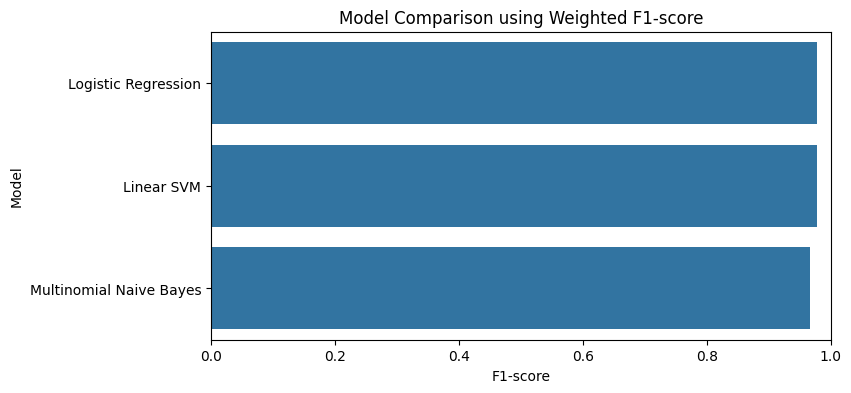

Best Model: Logistic Regression


In [13]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="F1-score", y="Model")
plt.title("Model Comparison using Weighted F1-score")
plt.xlim(0.0, 1.0)
plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

## **11. Confusion Matrix for Best Model**

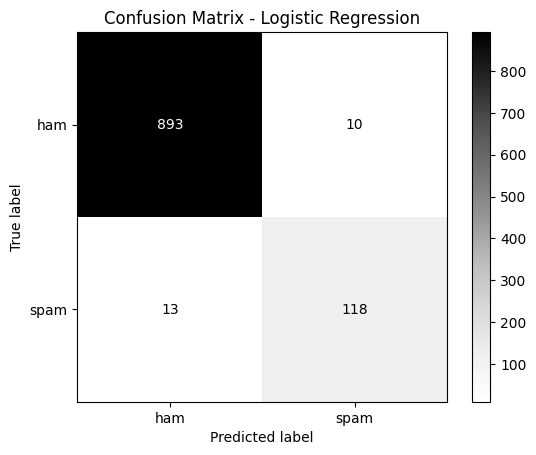

In [14]:
y_best_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, y_best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(cmap="Greys")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## **12. Test the Model on Custom Messages**

In [15]:
sample_messages = [
    "Congratulations! You have won a free prize. Call now to claim.",
    "Hi, can we meet tomorrow for the project discussion?",
    "URGENT! Your account has been selected for a cash reward."
]

cleaned_samples = [clean_text(msg) for msg in sample_messages]
sample_predictions = best_model.predict(cleaned_samples)

for msg, pred in zip(sample_messages, sample_predictions):
    label = "spam" if pred == 1 else "ham"
    print(f"Message: {msg}")
    print(f"Prediction: {label}")
    print("-" * 70)

Message: Congratulations! You have won a free prize. Call now to claim.
Prediction: spam
----------------------------------------------------------------------
Message: Hi, can we meet tomorrow for the project discussion?
Prediction: ham
----------------------------------------------------------------------
Message: URGENT! Your account has been selected for a cash reward.
Prediction: spam
----------------------------------------------------------------------


## 13. Save Best Model

In [16]:
joblib.dump(best_model, "email_spam_classifier.pkl")
print("Model saved as email_spam_classifier.pkl")

Model saved as email_spam_classifier.pkl
